# Optimization with Linear Programming in Python (PuLP)
## Business Problem: Production Planning for a Small Manufacturer

This notebook demonstrates how to solve a real business problem using **optimization (Linear Programming)** and **PuLP**.

**Goal:** Decide how much of each product to produce this week to **maximize profit** while respecting constraints like:
- Limited machine hours
- Limited labor hours
- Limited raw material
- Minimum customer commitments (must produce at least some quantity)

We’ll also extract **insights**:
- Which resource is the bottleneck?
- What’s the marginal value of extra capacity (shadow prices)?
- What changes if we increase a resource by 10%?


In [1]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [2]:
# If PuLP isn't installed in your environment, uncomment the next line:
# !pip -q install pulp

import pandas as pd
import numpy as np
from pulp import (
    LpProblem, LpMaximize, LpVariable, lpSum,
    LpStatus, value, PULP_CBC_CMD
)

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1) Data Setup
Imagine a small manufacturing unit making **3 products** (A, B, C). Each product consumes:
- **Machine hours**
- **Labor hours**
- **Raw material (kg)**

Each product also has a **profit per unit** and a **minimum commitment** to customers.


In [3]:
products = ["A", "B", "C"]

data = pd.DataFrame({
    "profit_per_unit": [50, 40, 65],         # ₹ per unit
    "machine_hours":   [2.0, 1.0, 3.0],      # hours per unit
    "labor_hours":     [1.0, 2.0, 1.5],      # hours per unit
    "material_kg":     [3.0, 2.0, 4.0],      # kg per unit
    "min_commitment":  [10, 20, 5],          # units (must produce at least)
    "max_demand":      [80, 120, 60],        # units (can't sell above this)
}, index=products)

capacity = {
    "machine_hours": 220,  # total machine hours available this week
    "labor_hours":   200,  # total labor hours available this week
    "material_kg":   300,  # total raw material available (kg)
}

data, capacity

(   profit_per_unit  machine_hours  labor_hours  material_kg  min_commitment  \
 A               50           2.00         1.00         3.00              10   
 B               40           1.00         2.00         2.00              20   
 C               65           3.00         1.50         4.00               5   
 
    max_demand  
 A          80  
 B         120  
 C          60  ,
 {'machine_hours': 220, 'labor_hours': 200, 'material_kg': 300})

## 2) Model Formulation (Linear Programming)
### Decision Variables
- Let **x[p]** = units of product *p* to produce this week.

### Objective
- **Maximize total profit**:
\[
\max \sum_p profit[p] \cdot x[p]
\]

### Constraints
- Resource limits (machine, labor, material)
- Minimum commitments (must produce at least some units)
- Maximum demand (can't produce more than you can sell)


In [4]:
# Create the optimization model
model = LpProblem("Production_Planning", LpMaximize)

# Decision variables: units to produce for each product
x = {
    p: LpVariable(f"x_{p}", lowBound=0)  # continuous variables (LP)
    for p in products
}

# Objective: maximize profit
model += lpSum(data.loc[p, "profit_per_unit"] * x[p] for p in products), "Total_Profit"

# Resource constraints
model += lpSum(data.loc[p, "machine_hours"] * x[p] for p in products) <= capacity["machine_hours"], "Machine_Hours"
model += lpSum(data.loc[p, "labor_hours"]   * x[p] for p in products) <= capacity["labor_hours"],   "Labor_Hours"
model += lpSum(data.loc[p, "material_kg"]   * x[p] for p in products) <= capacity["material_kg"],   "Material_kg"

# Demand & commitment constraints
for p in products:
    model += x[p] >= data.loc[p, "min_commitment"], f"MinCommit_{p}"
    model += x[p] <= data.loc[p, "max_demand"],     f"MaxDemand_{p}"

model

Production_Planning:
MAXIMIZE
50*x_A + 40*x_B + 65*x_C + 0.0
SUBJECT TO
Machine_Hours: 2 x_A + x_B + 3 x_C <= 220

Labor_Hours: x_A + 2 x_B + 1.5 x_C <= 200

Material_kg: 3 x_A + 2 x_B + 4 x_C <= 300

MinCommit_A: x_A >= 10

MaxDemand_A: x_A <= 80

MinCommit_B: x_B >= 20

MaxDemand_B: x_B <= 120

MinCommit_C: x_C >= 5

MaxDemand_C: x_C <= 60

VARIABLES
x_A Continuous
x_B Continuous
x_C Continuous

## 3) Solve the Model
We’ll use PuLP’s default CBC solver.


In [5]:
solver = PULP_CBC_CMD(msg=False)  # set msg=True to see solver logs
status = model.solve(solver)

LpStatus[status], value(model.objective)

('Optimal', 5487.5)

## 4) Results
### Optimal Production Plan


In [6]:
solution = pd.DataFrame({
    "produce_units": [x[p].value() for p in products],
    "profit_per_unit": data["profit_per_unit"].values
}, index=products)

solution["profit_contribution"] = solution["produce_units"] * solution["profit_per_unit"]
solution.loc["TOTAL"] = [solution["produce_units"].sum(), np.nan, solution["profit_contribution"].sum()]
solution

,produce_units,profit_per_unit,profit_contribution
A,43.75,50.00,"2,187.50"
B,74.38,40.00,"2,975.00"
C,5.00,65.00,325.00
TOTAL,123.12,NaN,"5,487.50"


### Resource Utilization
This shows how much of each capacity is used and whether the constraint is binding (fully used).


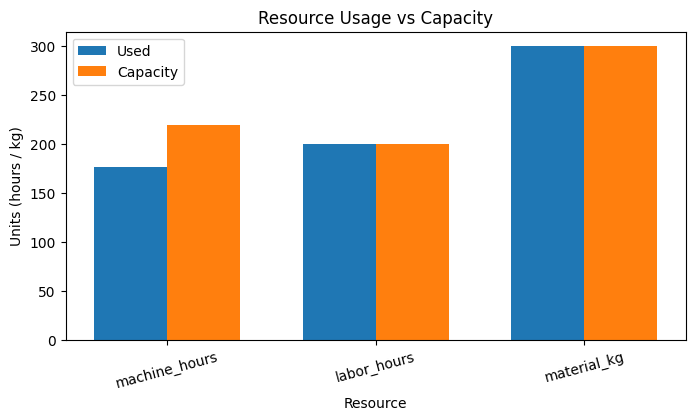

In [7]:
usage = {}
for res in ["machine_hours", "labor_hours", "material_kg"]:
    used = sum(data.loc[p, res] * x[p].value() for p in products)
    usage[res] = {"used": used, "capacity": capacity[res], "slack": capacity[res] - used}

usage_df = pd.DataFrame(usage).T
usage_df["utilization_%"] = 100 * usage_df["used"] / usage_df["capacity"]
usage_df
import matplotlib.pyplot as plt
import numpy as np

labels = usage_df.index.tolist()
used = usage_df["used"].values
cap = usage_df["capacity"].values

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,4))
plt.bar(x - width/2, used, width, label="Used")
plt.bar(x + width/2, cap,  width, label="Capacity")

plt.title("Resource Usage vs Capacity")
plt.xlabel("Resource")
plt.ylabel("Units (hours / kg)")
plt.xticks(x, labels, rotation=15)
plt.legend()
plt.show()


## 5) Business Insights
### 5.1 Bottleneck Identification
A constraint is typically a bottleneck if it is **binding** (slack ≈ 0).

In [8]:
binding = usage_df.assign(binding=lambda d: np.isclose(d["slack"], 0, atol=1e-6))
binding[["used", "capacity", "slack", "binding"]]

,used,capacity,slack,binding
machine_hours,176.88,220.00,43.12,False
labor_hours,200.00,200.00,0.00,True
material_kg,300.00,300.00,0.00,True


### 5.2 Shadow Prices (Marginal Value of Capacity)
In linear programming, the **shadow price** of a resource constraint tells you:
- **How much total profit increases** if you add **1 more unit** of that resource (e.g., +1 machine hour),
- **as long as the current optimal basis remains valid** (small changes).

CBC provides dual values for constraints (when available). We’ll extract them:


In [9]:
# Extract dual values (shadow prices) and slacks for key constraints
rows = []
for cname, c in model.constraints.items():
    # Some solvers expose .pi (dual) and .slack on constraints; CBC usually does.
    dual = getattr(c, "pi", None)
    slack = getattr(c, "slack", None)
    rows.append([cname, dual, slack])

duals = pd.DataFrame(rows, columns=["constraint", "shadow_price", "slack"])

# Focus on resource constraints
duals[duals["constraint"].isin(["Machine_Hours", "Labor_Hours", "Material_kg"])].reset_index(drop=True)

,constraint,shadow_price,slack
0,Machine_Hours,-0.00,43.12
1,Labor_Hours,5.00,-0.00
2,Material_kg,15.00,-0.00


**Interpretation tip:**
- If a resource constraint is **not binding** (slack > 0), its shadow price is usually **0**.
- If it’s binding, a positive shadow price means that adding more of that resource can increase profit.


## 6) What-if Analysis: Increase a Capacity by 10%
We’ll re-solve the model after increasing each capacity by 10% (one at a time) and compare profits.


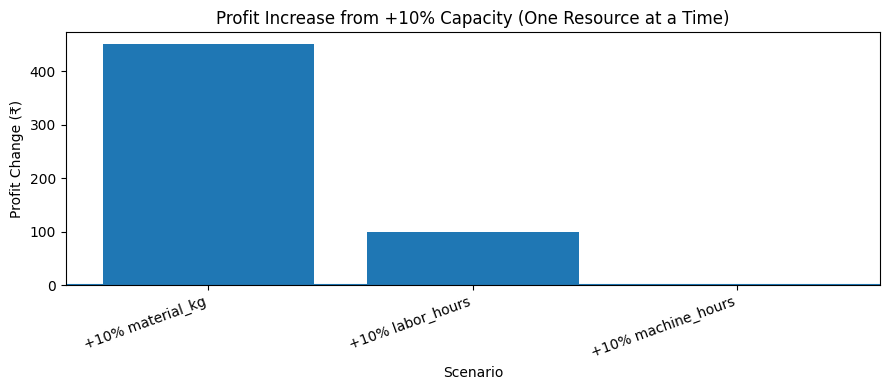

In [10]:
def solve_with_capacity(cap_override):
    m = LpProblem("WhatIf", LpMaximize)
    xx = {p: LpVariable(f"x_{p}", lowBound=0) for p in products}
    m += lpSum(data.loc[p, "profit_per_unit"] * xx[p] for p in products)
    m += lpSum(data.loc[p, "machine_hours"] * xx[p] for p in products) <= cap_override["machine_hours"]
    m += lpSum(data.loc[p, "labor_hours"]   * xx[p] for p in products) <= cap_override["labor_hours"]
    m += lpSum(data.loc[p, "material_kg"]   * xx[p] for p in products) <= cap_override["material_kg"]
    for p in products:
        m += xx[p] >= data.loc[p, "min_commitment"]
        m += xx[p] <= data.loc[p, "max_demand"]
    m.solve(PULP_CBC_CMD(msg=False))
    sol = {p: xx[p].value() for p in products}
    return value(m.objective), sol

base_profit, base_sol = solve_with_capacity(capacity)

scenarios = []
for res in capacity.keys():
    cap2 = dict(capacity)
    cap2[res] = cap2[res] * 1.10
    prof, sol = solve_with_capacity(cap2)
    scenarios.append({
        "scenario": f"+10% {res}",
        "profit": prof,
        "profit_change": prof - base_profit,
        **{f"x_{p}": sol[p] for p in products}
    })

scenario_df = pd.DataFrame(scenarios).sort_values("profit_change", ascending=False)
scenario_df
import matplotlib.pyplot as plt

tmp = scenario_df.copy()
tmp = tmp.sort_values("profit_change", ascending=False)

plt.figure(figsize=(9,4))
plt.bar(tmp["scenario"], tmp["profit_change"])
plt.title("Profit Increase from +10% Capacity (One Resource at a Time)")
plt.xlabel("Scenario")
plt.ylabel("Profit Change (₹)")
plt.xticks(rotation=20, ha="right")
plt.axhline(0)
plt.tight_layout()
plt.show()

## 7) Optional Extension: Integer (Batch) Production
In real operations, you might produce in **batches** (e.g., multiples of 5 units). We can model this with **integer variables**.

Here, we force production to be in multiples of 5 units:
- Let **y[p]** be an integer number of batches.
- Then **x[p] = 5 * y[p]**.


In [11]:
batch_size = 5

m_int = LpProblem("Production_Planning_Integer_Batches", LpMaximize)
y = {p: LpVariable(f"y_{p}", lowBound=0, cat="Integer") for p in products}

# x = batch_size * y
m_int += lpSum(data.loc[p, "profit_per_unit"] * (batch_size * y[p]) for p in products)

m_int += lpSum(data.loc[p, "machine_hours"] * (batch_size * y[p]) for p in products) <= capacity["machine_hours"]
m_int += lpSum(data.loc[p, "labor_hours"]   * (batch_size * y[p]) for p in products) <= capacity["labor_hours"]
m_int += lpSum(data.loc[p, "material_kg"]   * (batch_size * y[p]) for p in products) <= capacity["material_kg"]

for p in products:
    m_int += (batch_size * y[p]) >= data.loc[p, "min_commitment"]
    m_int += (batch_size * y[p]) <= data.loc[p, "max_demand"]

m_int.solve(PULP_CBC_CMD(msg=False))

int_solution = pd.DataFrame({
    "batches": [y[p].value() for p in products],
    "produce_units": [batch_size * y[p].value() for p in products],
    "profit_per_unit": data["profit_per_unit"].values
}, index=products)
int_solution["profit_contribution"] = int_solution["produce_units"] * int_solution["profit_per_unit"]
int_solution.loc["TOTAL"] = [int_solution["batches"].sum(), int_solution["produce_units"].sum(), np.nan, int_solution["profit_contribution"].sum()]

LpStatus[m_int.status], value(m_int.objective), int_solution

('Optimal',
 5450.0,
        batches  produce_units  profit_per_unit  profit_contribution
 A         8.00          40.00            50.00             2,000.00
 B        14.00          70.00            40.00             2,800.00
 C         2.00          10.00            65.00               650.00
 TOTAL    24.00         120.00              NaN             5,450.00)

## 8) Summary (What You’d Say in a Presentation)
- Built a linear programming model to decide weekly production quantities.
- Maximized profit while meeting commitments and staying within machine/labor/material limits.
- Identified which resources are binding (bottlenecks) and used shadow prices to estimate the value of extra capacity.
- Ran what-if scenarios to quantify ROI of adding capacity.
- Extended the model to an integer (batch) version to reflect real manufacturing constraints.

**Next steps:**
- Add setup costs, overtime cost tiers, multi-week inventory, or multiple plants/warehouses.
- Integrate with real ERP data and automate weekly planning.


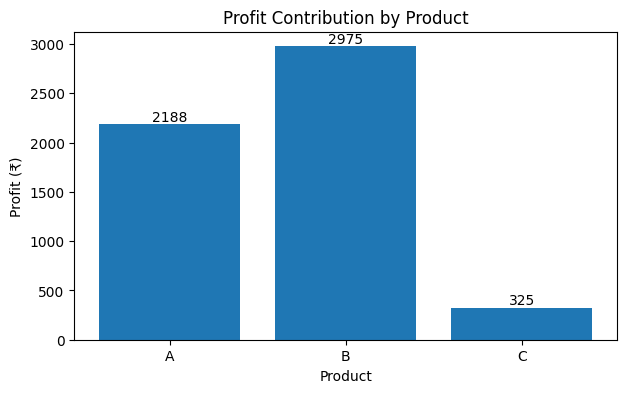

In [12]:
import matplotlib.pyplot as plt

# Profit contribution per product
plot_df = solution.drop(index="TOTAL", errors="ignore").copy()

plt.figure(figsize=(7,4))
plt.bar(plot_df.index, plot_df["profit_contribution"])
plt.title("Profit Contribution by Product")
plt.xlabel("Product")
plt.ylabel("Profit (₹)")
for i, v in enumerate(plot_df["profit_contribution"].values):
    plt.text(i, v, f"{v:.0f}", ha="center", va="bottom")
plt.show()